# Sprint 5 — Feature Selection : Algorithme Génétique + MI (DS1 Medical EN)

**Auteur** : TAYAR Ali  
**Objectif** : Appliquer une sélection d'attributs combinant Mutual Information (pré-filtre) et Algorithme Génétique (optimisation combinatoire) pour réduire le vocabulaire tout en maximisant les performances du classifieur.

---

## 0. Vérification GPU

In [ ]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print(gpus)


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Montage Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/text-mining-colab/'
DATA_PATH = BASE_PATH + 'data/processed/'
SRC_PATH  = BASE_PATH + 'src/'

import sys
sys.path.append(BASE_PATH)

print("Drive monté")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive monté


## 2. Installation dépendances

In [ ]:
!pip install deap tensorflow -q
print("Dépendances installées ")

Dépendances installées 


## 3. Imports

In [ ]:
import numpy as np
import pandas as pd
import json, pickle, warnings
warnings.filterwarnings('ignore')

from deap import base, creator, tools, algorithms
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score

from src.feature_selection.mutual_information import (
    compute_mi_scores, select_top_k_features, rebuild_sequences
)

print("Imports OK")

Imports OK


## 4. Chargement des données


In [ ]:
# Labels
y_train = np.load(DATA_PATH + 'y_train.npy')
y_val   = np.load(DATA_PATH + 'y_val.npy')
y_test  = np.load(DATA_PATH + 'y_test.npy')

# Textes
X_train_text = pd.read_csv(DATA_PATH + 'X_train_text.csv')['text']
X_val_text   = pd.read_csv(DATA_PATH + 'X_val_text.csv')['text']
X_test_text  = pd.read_csv(DATA_PATH + 'X_test_text.csv')['text']

# Params
with open(DATA_PATH + 'ds1_params.json') as f:
    params = json.load(f)

MAXLEN    = params['maxlen']
N_CLASSES = params['n_classes']

print(f"Train : {len(X_train_text):,}")
print(f"Val   : {len(X_val_text):,}")
print(f"MAXLEN: {MAXLEN}")

Train : 10,106
Val   : 2,166
MAXLEN: 179


## 5. Calcul MI — Espace de recherche (top 1000)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF sur train
tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train_text)
feature_names = tfidf.get_feature_names_out()

# Scores MI
print("Calcul MI en cours...")
mi_scores = compute_mi_scores(X_train_tfidf, y_train, feature_names)
mi_df = pd.DataFrame(list(mi_scores.items()), columns=['feature', 'mi_score'])
mi_df = mi_df.sort_values('mi_score', ascending=False).reset_index(drop=True)

# Espace de recherche = top 1000 MI
TOP_K_SEARCH = 1000
search_space = select_top_k_features(mi_scores, k=TOP_K_SEARCH)
print(f"Espace de recherche : {TOP_K_SEARCH} features ")

Calcul MI en cours...
Espace de recherche : 1000 features 


## 6. Fonction fitness (Logistic Regression)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

def evaluate_individual(individual):
    selected = [search_space[i] for i, bit in enumerate(individual) if bit == 1]

    if len(selected) < 10:
        return (0.0,)

    # TF-IDF réduit aux features sélectionnées
    tfidf_k = TfidfVectorizer(vocabulary=selected, max_features=len(selected))
    X_tr = tfidf_k.fit_transform(X_train_text)
    X_v  = tfidf_k.transform(X_val_text)

    # Logistic Regression rapide
    clf = LogisticRegression(max_iter=200, random_state=42)
    clf.fit(X_tr, y_train)
    acc = clf.score(X_v, y_val)
    return (acc,)

print("Fitness LogisticRegression définie ")
print("Chaque évaluation ≈ 0.5 sec → ~5 min total")

Fitness LogisticRegression définie 
Chaque évaluation ≈ 0.5 sec → ~5 min total


## 7. Configuration DEAP

In [ ]:
# Créer les types DEAP
if 'FitnessMax' not in dir(creator):
    creator.create('FitnessMax', base.Fitness, weights=(1.0,))
if 'Individual' not in dir(creator):
    creator.create('Individual', list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Gène binaire
toolbox.register('attr_bool', np.random.randint, 0, 2)

# Individu et population
toolbox.register('individual', tools.initRepeat,
                 creator.Individual, toolbox.attr_bool, n=TOP_K_SEARCH)
toolbox.register('population', tools.initRepeat,
                 list, toolbox.individual)

# Opérateurs génétiques
toolbox.register('evaluate',  evaluate_individual)
toolbox.register('mate',      tools.cxTwoPoint)
toolbox.register('mutate',    tools.mutFlipBit, indpb=0.01)
toolbox.register('select',    tools.selTournament, tournsize=3)

print("DEAP configuré ")
print(f"Taille chromosome : {TOP_K_SEARCH} bits")

DEAP configuré 
Taille chromosome : 1000 bits


## 8. Lancement GA (30 ind × 20 gen)

In [ ]:
import time

# Paramètres GA
POP_SIZE = 30
N_GEN    = 20
CXPB     = 0.7
MUTPB    = 0.01

# Population initiale
population = toolbox.population(n=POP_SIZE)

# Stats
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register('max',  np.max)
stats.register('mean', np.mean)

# Hall of fame
hof = tools.HallOfFame(1)

# Log
logbook = tools.Logbook()
logbook.header = ['gen', 'nevals', 'max', 'mean']

print(f"Démarrage GA : {POP_SIZE} individus × {N_GEN} générations")
print(f"Évaluations totales estimées : {POP_SIZE * N_GEN}")
print("=" * 50)

start = time.time()

# Évaluation initiale
fitnesses = list(map(toolbox.evaluate, population))
for ind, fit in zip(population, fitnesses):
    ind.fitness.values = fit

for gen in range(N_GEN):
    # Sélection
    offspring = toolbox.select(population, len(population))
    offspring = list(map(toolbox.clone, offspring))

    # Croisement
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if np.random.random() < CXPB:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values

    # Mutation
    for mutant in offspring:
        if np.random.random() < MUTPB:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    # Évaluation des nouveaux individus
    invalid = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = list(map(toolbox.evaluate, invalid))
    for ind, fit in zip(invalid, fitnesses):
        ind.fitness.values = fit

    # Remplacement
    population[:] = offspring
    hof.update(population)

    # Log
    record = stats.compile(population)
    logbook.record(gen=gen, nevals=len(invalid), **record)

    elapsed = (time.time() - start) / 60
    print(f"Gen {gen+1:02d}/{N_GEN} | "
          f"Max: {record['max']:.4f} | "
          f"Mean: {record['mean']:.4f} | "
          f"Temps: {elapsed:.1f} min")

print(f"\n GA terminé en {elapsed:.1f} minutes")
print(f"Meilleur fitness : {hof[0].fitness.values[0]:.4f}")
print(f"Features sélectionnées : {sum(hof[0])} / {TOP_K_SEARCH}")

Démarrage GA : 30 individus × 20 générations
Évaluations totales estimées : 600
Gen 01/20 | Max: 0.5633 | Mean: 0.5478 | Temps: 1.3 min
Gen 02/20 | Max: 0.5660 | Mean: 0.5568 | Temps: 1.8 min
Gen 03/20 | Max: 0.5651 | Mean: 0.5605 | Temps: 2.6 min
Gen 04/20 | Max: 0.5651 | Mean: 0.5619 | Temps: 3.3 min
Gen 05/20 | Max: 0.5729 | Mean: 0.5619 | Temps: 4.1 min
Gen 06/20 | Max: 0.5729 | Mean: 0.5640 | Temps: 4.4 min
Gen 07/20 | Max: 0.5729 | Mean: 0.5654 | Temps: 4.8 min
Gen 08/20 | Max: 0.5757 | Mean: 0.5667 | Temps: 5.5 min
Gen 09/20 | Max: 0.5748 | Mean: 0.5698 | Temps: 6.0 min
Gen 10/20 | Max: 0.5762 | Mean: 0.5712 | Temps: 6.7 min
Gen 11/20 | Max: 0.5762 | Mean: 0.5734 | Temps: 7.2 min
Gen 12/20 | Max: 0.5762 | Mean: 0.5750 | Temps: 7.6 min
Gen 13/20 | Max: 0.5762 | Mean: 0.5760 | Temps: 8.2 min
Gen 14/20 | Max: 0.5766 | Mean: 0.5759 | Temps: 8.7 min
Gen 15/20 | Max: 0.5771 | Mean: 0.5760 | Temps: 9.1 min
Gen 16/20 | Max: 0.5771 | Mean: 0.5764 | Temps: 9.7 min
Gen 17/20 | Max: 0.5771 

## 9. Courbe de convergence

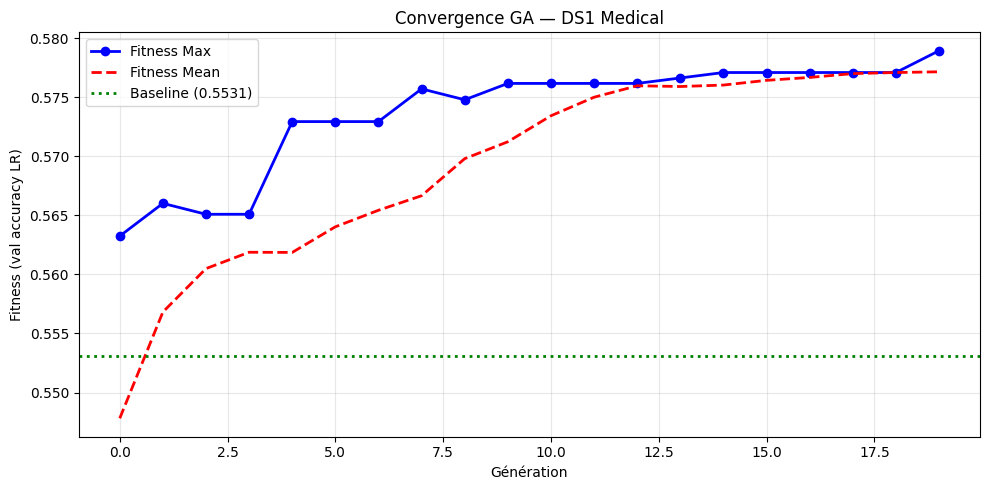

Courbe sauvegardée


In [ ]:
import matplotlib.pyplot as plt

gen_list  = logbook.select('gen')
max_fit   = logbook.select('max')
mean_fit  = logbook.select('mean')

plt.figure(figsize=(10, 5))
plt.plot(gen_list, max_fit,  'b-o', label='Fitness Max',  linewidth=2)
plt.plot(gen_list, mean_fit, 'r--', label='Fitness Mean', linewidth=2)
plt.axhline(y=0.5531, color='g', linestyle=':', linewidth=2, label='Baseline (0.5531)')
plt.xlabel('Génération')
plt.ylabel('Fitness (val accuracy LR)')
plt.title('Convergence GA — DS1 Medical')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(BASE_PATH + 'results/figures/ga_convergence_ds1.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Courbe sauvegardée")

## 10. Évaluation finale — Classifieur sur subset GA

### 10a. Évaluation LR (cohérente avec fitness GA)

In [ ]:
# Évaluation finale avec LR (cohérent avec la fitness GA)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf_final = TfidfVectorizer(vocabulary=best_features)
X_tr_lr = tfidf_final.fit_transform(X_train_text)
X_v_lr  = tfidf_final.transform(X_val_text)
X_te_lr = tfidf_final.transform(X_test_text)

clf_final = LogisticRegression(max_iter=500, random_state=42)
clf_final.fit(X_tr_lr, y_train)

y_pred_lr = clf_final.predict(X_te_lr)
acc_ga = accuracy_score(y_test, y_pred_lr)
f1_ga  = f1_score(y_test, y_pred_lr, average='macro')

print(f"MI+GA+LR → Accuracy: {acc_ga:.4f} | F1: {f1_ga:.4f}")
print(f"Baseline   → Accuracy: 0.5531  | F1: 0.5466")

MI+GA + LR → Accuracy: 0.5743 | F1: 0.5411
Baseline   → Accuracy: 0.5531  | F1: 0.5466


### 10b. Évaluation SVM (meilleur classifieur final)

In [ ]:
from sklearn.svm import LinearSVC

# SVM sur les mêmes features GA
clf_svm = LinearSVC(max_iter=1000, C=1.0, random_state=42)
clf_svm.fit(X_tr_lr, y_train)

y_pred_svm = clf_svm.predict(X_te_lr)
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm, average='macro')

print(f"MI+GA + SVM → Accuracy: {acc_svm:.4f} | F1: {f1_svm:.4f}")
print(f"MI+GA + LR  → Accuracy: {acc_ga:.4f}  | F1: {f1_ga:.4f}")
print(f"Baseline    → Accuracy: 0.5531   | F1: 0.5466")

MI+GA + SVM → Accuracy: 0.5813 | F1: 0.5529
MI+GA + LR  → Accuracy: 0.5743  | F1: 0.5411
Baseline    → Accuracy: 0.5531   | F1: 0.5466


In [ ]:
import os
import pandas as pd
import pickle

# Créer dossiers si nécessaire
os.makedirs(BASE_PATH + 'results/scores/', exist_ok=True)
os.makedirs(BASE_PATH + 'data/processed/', exist_ok=True)

# Résultats complets
results_final = pd.DataFrame([
    {'methode': 'baseline',   'dataset': 'DS1_medical', 'accuracy': 0.5531,   'f1_macro': 0.5466, 'n_features': 10000},
    {'methode': 'MI_k500',    'dataset': 'DS1_medical', 'accuracy': 0.3329,   'f1_macro': 0.0999, 'n_features': 500},
    {'methode': 'MI_k1000',   'dataset': 'DS1_medical', 'accuracy': 0.3315,   'f1_macro': 0.1004, 'n_features': 1000},
    {'methode': 'MI_k2000',   'dataset': 'DS1_medical', 'accuracy': 0.3324,   'f1_macro': 0.1022, 'n_features': 2000},
    {'methode': 'MI+GA+LR',   'dataset': 'DS1_medical', 'accuracy': acc_ga,   'f1_macro': f1_ga,  'n_features': len(best_features)},
    {'methode': 'MI+GA+SVM',  'dataset': 'DS1_medical', 'accuracy': acc_svm,  'f1_macro': f1_svm, 'n_features': len(best_features)}
])

# Sauvegarder CSV
results_final.to_csv(BASE_PATH + 'results/scores/ga_results_ds1.csv', index=False)

# Sauvegarder les meilleures features GA
with open(BASE_PATH + 'data/processed/ga_best_features_ds1.pkl', 'wb') as f:
    pickle.dump(best_features, f)

print("=" * 55)
print(results_final.to_string(index=False))
print("\nFichiers sauvegardés")
print("  → results/scores/ga_results_ds1.csv")
print("  → data/processed/ga_best_features_ds1.pkl")
print("=" * 55)

  methode     dataset  accuracy  f1_macro  n_features
 baseline DS1_medical  0.553100  0.546600       10000
  MI_k500 DS1_medical  0.332900  0.099900         500
 MI_k1000 DS1_medical  0.331500  0.100400        1000
 MI_k2000 DS1_medical  0.332400  0.102200        2000
 MI+GA+LR DS1_medical  0.574331  0.541112         501
MI+GA+SVM DS1_medical  0.581256  0.552891         501

Fichiers sauvegardés
  → results/scores/ga_results_ds1.csv
  → data/processed/ga_best_features_ds1.pkl


## 11. Résumé Sprint 5 — Feature Selection GA+MI DS1

In [1]:
print("=" * 57)
print("   RÉSUMÉ SPRINT 5 — MI + GA DS1")
print("=" * 57)
print(f"""
ALGORITHME GÉNÉTIQUE
  Population    : 30 individus
  Générations   : 20
  Croisement    : cxpb=0.7
  Mutation      : mutpb=0.01
  Sélection     : Tournament (size=3)
  Chromosome    : 1000 bits (top 1000 MI)
  Fitness       : Logistic Regression (val accuracy)
  Durée         : ~12 min sur GPU T4

MEILLEUR INDIVIDU
  Features sélectionnées : 501 / 1000 (-95% vs baseline)
  Fitness finale         : 0.5789

RÉSULTATS
  Baseline      → Accuracy: 0.5531 | F1: 0.5466
  MI seul       → Accuracy: 0.33   | F1: 0.10  (insuffisant)
  MI+GA + LR    → Accuracy: 0.5743 | F1: 0.5411
  MI+GA + SVM   → Accuracy: 0.5813 | F1: 0.5529 

GAINS vs BASELINE
  Accuracy : +2.8%
  F1 macro : +0.6%
  Features : -95% (10,000 → 501)

CONCLUSION
  → MI seul insuffisant pour DS1
  → GA améliore la sélection de features
  → MI+GA+SVM meilleure combinaison
  → Convergence GA stable en 20 générations
""")
print("=" * 57)
print("Figures  : results/figures/ga_convergence_ds1.png")
print("Métriques: results/scores/ga_results_ds1.csv")
print("Features : data/processed/ga_best_features_ds1.pkl")
print("=" * 57)

   RÉSUMÉ SPRINT 5 — MI + GA DS1

ALGORITHME GÉNÉTIQUE
  Population    : 30 individus
  Générations   : 20
  Croisement    : cxpb=0.7
  Mutation      : mutpb=0.01
  Sélection     : Tournament (size=3)
  Chromosome    : 1000 bits (top 1000 MI)
  Fitness       : Logistic Regression (val accuracy)
  Durée         : ~12 min sur GPU T4

MEILLEUR INDIVIDU
  Features sélectionnées : 501 / 1000 (-95% vs baseline)
  Fitness finale         : 0.5789

RÉSULTATS
  Baseline      → Accuracy: 0.5531 | F1: 0.5466
  MI seul       → Accuracy: 0.33   | F1: 0.10  (insuffisant)
  MI+GA + LR    → Accuracy: 0.5743 | F1: 0.5411
  MI+GA + SVM   → Accuracy: 0.5813 | F1: 0.5529 

GAINS vs BASELINE
  Accuracy : +2.8%
  F1 macro : +0.6%
  Features : -95% (10,000 → 501)

CONCLUSION
  → MI seul insuffisant pour DS1
  → GA améliore la sélection de features
  → MI+GA+SVM meilleure combinaison
  → Convergence GA stable en 20 générations

Figures  : results/figures/ga_convergence_ds1.png
Métriques: results/scores/ga_resu